In [53]:
from dataclasses import dataclass
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.backends.cudnn.benchmark = True

@dataclass
class CharGPTConfig:
    # Training hyperparameters
    num_epochs: int = 7  # Reduced to combat overfitting
    batch_size: int = 64
    block_size: int = 256
    learning_rate: float = 3e-4
    weight_decay: float = 0.05  # Increased for stronger regularization
    grad_clip: float = 1.0
    use_early_stopping: bool = True # New flag to control early stopping

    # Model parameters
    n_layers: int = 3  # Reduced layers for lower capacity
    n_heads: int = 6   # Reduced heads for lower capacity
    emb_dim: int = 258  # Reduced embedding dimension (still divisible by n_heads) - Changed from 254 to 258
    vocab_size: int = -1
    dropout: float = 0.2  # Increased for stronger regularization

    # Optimization
    compile_model: bool = True
    use_mixed_precision: bool = True


class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.block_size]
        y = self.data[idx + 1: idx + self.block_size + 1]
        return x, y


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.emb_dim % config.n_heads == 0

        self.emb_dim = config.emb_dim
        self.n_heads = config.n_heads
        self.head_dim = config.emb_dim // config.n_heads

        # Combined QKV projection for efficiency
        self.c_attn = nn.Linear(config.emb_dim, 3 * config.emb_dim, bias=False)
        self.c_proj = nn.Linear(config.emb_dim, config.emb_dim, bias=False)

        self.dropout = config.dropout
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')

        if not self.flash:
            # Create causal mask for non-flash attention
            self.register_buffer(
                "mask",
                torch.tril(torch.ones(config.block_size, config.block_size))
                .view(1, 1, config.block_size, config.block_size)
            )

    def forward(self, x):
        B, T, C = x.shape

        # Calculate QKV in one go
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.emb_dim, dim=2)

        # Reshape for multi-head attention
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, n_heads, T, head_dim)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        if self.flash:
            # Use Flash Attention
            out = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # Manual attention computation
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = F.dropout(att, p=self.dropout, training=self.training)
            out = att @ v

        # Concatenate heads and project
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.c_proj(out)

        return out


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Use 4x expansion as in GPT
        hidden_dim = 4 * config.emb_dim
        self.c_fc = nn.Linear(config.emb_dim, hidden_dim, bias=False)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(hidden_dim, config.emb_dim, bias=False)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.emb_dim)
        self.attn = MultiHeadAttention(config)
        self.ln_2 = nn.LayerNorm(config.emb_dim)
        self.mlp = FeedForward(config)

    def forward(self, x):
        # Pre-norm architecture (more stable)
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class CharGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # Token and position embeddings
        self.tok_emb = nn.Embedding(config.vocab_size, config.emb_dim)
        self.pos_emb = nn.Embedding(config.block_size, config.emb_dim)
        self.drop = nn.Dropout(config.dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])

        # Final layer norm and output projection
        self.ln_f = nn.LayerNorm(config.emb_dim)
        self.lm_head = nn.Linear(config.emb_dim, config.vocab_size, bias=False)

        # Weight tying (tie input and output embeddings)
        self.tok_emb.weight = self.lm_head.weight

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Create position indices
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device).unsqueeze(0)  # (1, T)

        # Token and position embeddings
        tok_emb = self.tok_emb(idx)  # (B, T, emb_dim)
        pos_emb = self.pos_emb(pos)  # (1, T, emb_dim)
        x = self.drop(tok_emb + pos_emb)

        # Apply transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final layer norm and projection
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            # Crop sequence if it exceeds block size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]

            # Forward pass
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Sample from distribution
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


def create_data_loaders(data, config, train_split=0.9):
    """Create efficient data loaders with proper splitting"""
    n = int(train_split * len(data))
    train_data = data[:n]
    val_data = data[n:]

    train_dataset = CharDataset(train_data, config.block_size)
    val_dataset = CharDataset(val_data, config.block_size)

    # Determine optimal number of workers (avoid warning)
    import os
    num_workers = min(4, os.cpu_count() or 2)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True if num_workers > 0 else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True if num_workers > 0 else False
    )

    return train_loader, val_loader


def estimate_loss(model, data_loader, device, max_batches=10):
    """Estimate loss on a subset of data for faster evaluation"""
    model.eval()
    losses = []

    with torch.no_grad():
        for i, (xb, yb) in enumerate(data_loader):
            if i >= max_batches:
                break
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            _, loss = model(xb, yb)
            losses.append(loss.item())

    return sum(losses) / len(losses)


def save_model_and_config(model, config, char_to_id, id_to_char, save_dir="models"):
    """Save the trained model, config, and vocabulary mappings"""
    import os
    import json

    # Create models directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Save model state dict
    model_path = os.path.join(save_dir, 'char_gpt_model.pth')
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to: {model_path}")

    # Save configuration
    config_dict = {
        'num_epochs': config.num_epochs,
        'batch_size': config.batch_size,
        'block_size': config.block_size,
        'learning_rate': config.learning_rate,
        'weight_decay': config.weight_decay,
        'grad_clip': config.grad_clip,
        'n_layers': config.n_layers,
        'n_heads': config.n_heads,
        'emb_dim': config.emb_dim,
        'vocab_size': config.vocab_size,
        'dropout': config.dropout,
        'compile_model': config.compile_model,
        'use_mixed_precision': config.use_mixed_precision,
        'use_early_stopping': config.use_early_stopping
    }

    config_path = os.path.join(save_dir, 'config.json')
    with open(config_path, 'w') as f:
        json.dump(config_dict, f, indent=2)
    print(f"Config saved to: {config_path}")

    # Save vocabulary mappings
    vocab_data = {
        'char_to_id': char_to_id,
        'id_to_char': id_to_char,
        'vocab_size': len(char_to_id)
    }

    vocab_path = os.path.join(save_dir, 'vocab.json')
    with open(vocab_path, 'w') as f:
        json.dump(vocab_data, f, indent=2)
    print(f"Vocabulary saved to: {vocab_path}")

    return model_path, config_path, vocab_path


def load_model_and_config(model_dir="models"):
    """Load a previously trained model"""
    import os
    import json

    # Load config
    config_path = os.path.join(model_dir, 'config.json')
    with open(config_path, 'r') as f:
        config_dict = json.load(f)

    # Recreate config object
    config = CharGPTConfig()
    for key, value in config_dict.items():
        setattr(config, key, value)

    # Load vocabulary
    vocab_path = os.path.join(model_dir, 'vocab.json')
    with open(vocab_path, 'r') as f:
        vocab_data = json.load(f)

    char_to_id = vocab_data['char_to_id']
    id_to_char = {int(k): v for k, v in vocab_data['id_to_char'].items()}  # Convert keys back to int

    # Load model
    model = CharGPT(config)
    model_path = os.path.join(model_dir, 'char_gpt_model.pth')
    model.load_state_dict(torch.load(model_path, map_location='cpu'))

    encoder = lambda s: [char_to_id[c] for c in s]
    decoder = lambda l: ''.join([id_to_char[i] for i in l])

    return model, config, char_to_id, id_to_char, encoder, decoder

## Refactor Training Loop



In [54]:
def train_one_epoch(model, train_loader, optimizer, scaler, config, device, epoch):
    model.train()
    epoch_loss = 0
    num_batches = 0

    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if config.use_mixed_precision and scaler is not None:
            try:
                # Use new API if available
                with torch.amp.autocast('cuda'):
                    logits, loss = model(xb, yb)
            except:
                # Fallback to old API
                with torch.cuda.amp.autocast():
                    logits, loss = model(xb, yb)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits, loss = model(xb, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

        # Print progress every 200 batches (less frequent)
        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1}/{config.num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")

    return epoch_loss / num_batches


In [55]:
def generate_sample_text(model, char_to_id, id_to_char, device, max_new_tokens=100, temperature=0.8, start_char='T'):
    model.eval()
    with torch.no_grad():
        # Ensure the starting character exists in the vocabulary
        if start_char not in char_to_id:
            # Fallback to the first character if the requested start_char is not available
            print(f"Warning: '{start_char}' not found in vocabulary. Using '{list(char_to_id.keys())[0]}' as starting character.")
            start_char_id = char_to_id[list(char_to_id.keys())[0]]
        else:
            start_char_id = char_to_id[start_char]

        context = torch.tensor([[start_char_id]], dtype=torch.long, device=device)

        # Generate text
        generated_ids = model.generate(context, max_new_tokens=max_new_tokens, temperature=temperature)

        # Decode the generated IDs into text
        generated_text = ''.join([id_to_char[idx.item()] for idx in generated_ids[0]])
    return generated_text

## Create Main Training Orchestrator



In [56]:
def run_training_workflow(model, config, train_loader, val_loader, char_to_id, id_to_char, device):
    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        betas=(0.9, 0.95)
    )

    scheduler = CosineAnnealingLR(optimizer, T_max=config.num_epochs)

    # Mixed precision training (updated API)
    if config.use_mixed_precision and torch.cuda.is_available():
        try:
            # Use new API if available (PyTorch 2.1+)
            scaler = torch.amp.GradScaler('cuda')
        except:
            # Fallback to old API
            scaler = torch.cuda.amp.GradScaler()
    else:
        scaler = None

    # Initialize lists to store metrics
    train_losses = []
    val_losses = []
    lrs = []

    # Early stopping parameters
    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 3 # Stop if val loss doesn't improve for 3 epochs
    best_model_state = None

    # Training loop
    print("Starting training...")
    for epoch in range(config.num_epochs):
        # Train one epoch
        avg_train_loss = train_one_epoch(model, train_loader, optimizer, scaler, config, device, epoch)

        # Update learning rate
        scheduler.step()

        # Validation
        val_loss = estimate_loss(model, val_loader, device)

        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        lrs.append(scheduler.get_last_lr()[0])

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f}, Val Loss {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

        # Early stopping check
        if config.use_early_stopping: # Only perform early stopping if enabled
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict() # Save best model state
                print(f"Validation loss improved. Best loss: {best_val_loss:.4f}")
            else:
                patience_counter += 1
                print(f"Validation loss did not improve. Patience: {patience_counter}/{early_stopping_patience}")
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping triggered after {epoch+1} epochs.")
                    break # Exit training loop

        # Generate sample text (less frequent)
        if epoch % 3 == 0 or epoch == config.num_epochs - 1:
            print("Generating sample text...")
            generated_text = generate_sample_text(model, char_to_id, id_to_char, device, max_new_tokens=100, temperature=0.8)
            print(f"Sample: {generated_text[:200]}...") # Truncate long samples
            print("-" * 50)

    print("Training completed!")

    # Load the best model state if early stopping occurred or if it's the end of training
    if config.use_early_stopping and best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Loaded best model state based on validation loss.")
    elif not config.use_early_stopping:
        print("Early stopping was disabled. Using model state from the last epoch.")

    # Save the trained model, config, and vocabulary mappings
    print("\nSaving model and configurations...")
    save_model_and_config(model, config, char_to_id, {str(k):v for k,v in id_to_char.items()})

    # Final generation
    model.eval()
    # Using 'T' as a common starting point, but any character from char_to_id.keys() can be used.
    # Ensure the key exists before attempting to access it.
    initial_char = 'T'
    if initial_char not in char_to_id:
        initial_char = list(char_to_id.keys())[0] # Fallback to the first character if 'T' is not available

    context = torch.tensor([[char_to_id[initial_char]]], dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=200, temperature=0.8)
    print("\nFinal generated text:")
    print(''.join([id_to_char[idx.item()] for idx in generated[0]]))

    print("Done!")

    return train_losses, val_losses, lrs

## Update Main Entry Point



In [57]:
config = CharGPTConfig()

def get_data():
  # Load and prepare data
    try:
        with open('/content/starwars.txt', 'r', encoding='utf-8') as f:
            text = f.read()
    except FileNotFoundError:
        print("Shakespeare file not found. Creating sample data...")
        text = "Hello world! " * 1000  # Sample data for testing

    # Use more data for better training
    text = text[:100000]  # Increased from 20000

    # Create vocabulary
    chars = sorted(list(set(text)))
    vocab_size = len(chars)
    config.vocab_size = vocab_size

    print(f"Vocabulary size: {vocab_size}")
    print(f"Dataset size: {len(text)} characters")

    # Create mappings
    char_to_id = {ch: idx for idx, ch in enumerate(chars)}
    id_to_char = {idx: ch for ch, idx in char_to_id.items()}

    encoder = lambda s: [char_to_id[c] for c in s]
    decoder = lambda l: ''.join([id_to_char[i] for i in l])

    # Encode data
    data = torch.tensor(encoder(text), dtype=torch.long)

    # Create data loaders
    train_loader, val_loader = create_data_loaders(data, config)
    return train_loader, val_loader, char_to_id, id_to_char


# The existing global calls to get_data() and its assignment need to be removed or commented out
# because the main function will now handle this. However, for a direct replacement of the cell,
# I'll include the modified get_data() and proceed with the main function in the next step.
# The original notebook had this line outside main, it should be moved inside the new main
# train_loader, val_loader = get_data()
# For now, just define the function, the main function will call it.

## Create Plotting Utility Function


In [58]:
import matplotlib.pyplot as plt

def plot_training_metrics(train_losses, val_losses, lrs):
    """
    Plots the training loss, validation loss, and learning rate over epochs.

    Args:
        train_losses (list): List of training loss values per epoch.
        val_losses (list): List of validation loss values per epoch.
        lrs (list): List of learning rates per epoch.
    """

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Plot Training and Validation Loss
    axes[0].plot(epochs, train_losses, label='Training Loss', color='blue')
    axes[0].plot(epochs, val_losses, label='Validation Loss', color='red')
    axes[0].set_title('Training and Validation Loss Over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot Learning Rate Schedule
    axes[1].plot(epochs, lrs, label='Learning Rate', color='green')
    axes[1].set_title('Learning Rate Schedule Over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("Defined plot_training_metrics function.")

Defined plot_training_metrics function.


# Training

In [59]:
import os
import json # Required for config loading if we decide to load full config

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Get data loaders and vocabulary mappings
    # This will set config.vocab_size based on the current dataset
    train_loader, val_loader, char_to_id, id_to_char = get_data()

    # Initialize model based on the current (potentially modified) config and vocab_size
    model = CharGPT(config).to(device)

    # Compile model for faster execution (PyTorch 2.0+) - Moved here to ensure model is compiled before loading state_dict
    if config.compile_model and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)
            print("Model compiled successfully!")
        except Exception as e:
            print(f"Model compilation failed: {e}")

    # Check for existing model to load weights
    model_dir = "models"
    model_path = os.path.join(model_dir, 'char_gpt_model.pth')
    config_path = os.path.join(model_dir, 'config.json') # Path to saved config, if needed
    vocab_path = os.path.join(model_dir, 'vocab.json') # Path to saved vocab

    if os.path.exists(model_path) and os.path.exists(config_path) and os.path.exists(vocab_path):
        print("\nSaved model found. Loading weights for continued training...")
        try:
            # For simplicity, we'll load only the state_dict into the model
            # initialized with the current config.vocab_size.
            # This assumes architectural parameters (n_layers, n_heads, emb_dim etc.)
            # in the global 'config' object are compatible or desired for the current run.
            model.load_state_dict(torch.load(model_path, map_location=device))
            print("Model weights loaded successfully.")
        except Exception as e:
            print(f"Error loading model weights: {e}. Training from scratch.")
            # If loading fails, re-initialize model (uncompiled, then compile if needed)
            model = CharGPT(config).to(device)
            if config.compile_model and hasattr(torch, 'compile'): # Recompile if the error path was taken
                try:
                    model = torch.compile(model)
                except Exception as e_recompile:
                    print(f"Model re-compilation failed: {e_recompile}")
    else:
        print("\nNo saved model found. Initializing new model from scratch.")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Run the training workflow and get the metrics
    train_losses, val_losses, lrs = run_training_workflow(model, config, train_loader, val_loader, char_to_id, id_to_char, device)

    return train_losses, val_losses, lrs


In [60]:
Flag = True

if Flag:
  train_losses, val_losses, lrs = main()

Using device: cuda
Vocabulary size: 67
Dataset size: 100000 characters
Model compiled successfully!

Saved model found. Loading weights for continued training...
Model weights loaded successfully.
Total parameters: 2,483,250
Trainable parameters: 2,483,250
Starting training...
Epoch 1/7, Batch 0, Loss: 0.1933
Epoch 1/7, Batch 200, Loss: 0.1844
Epoch 1/7, Batch 400, Loss: 0.1721
Epoch 1/7, Batch 600, Loss: 0.1643
Epoch 1: Train Loss 0.1821, Val Loss 3.8693, LR: 0.000285
Validation loss improved. Best loss: 3.8693
Generating sample text...
Sample: THREEPIO : I'm afraid I'm not quite sure, sir.
LEIA : Help me, Obi-Wan Kenobi...
THREEPIO : I think s...
--------------------------------------------------
Epoch 2/7, Batch 0, Loss: 0.1647
Epoch 2/7, Batch 200, Loss: 0.1536
Epoch 2/7, Batch 400, Loss: 0.1468
Epoch 2/7, Batch 600, Loss: 0.1460
Epoch 2: Train Loss 0.1525, Val Loss 4.0613, LR: 0.000244
Validation loss did not improve. Patience: 1/3
Epoch 3/7, Batch 0, Loss: 0.1471
Epoch 3/7, Batch


Plotting training metrics...


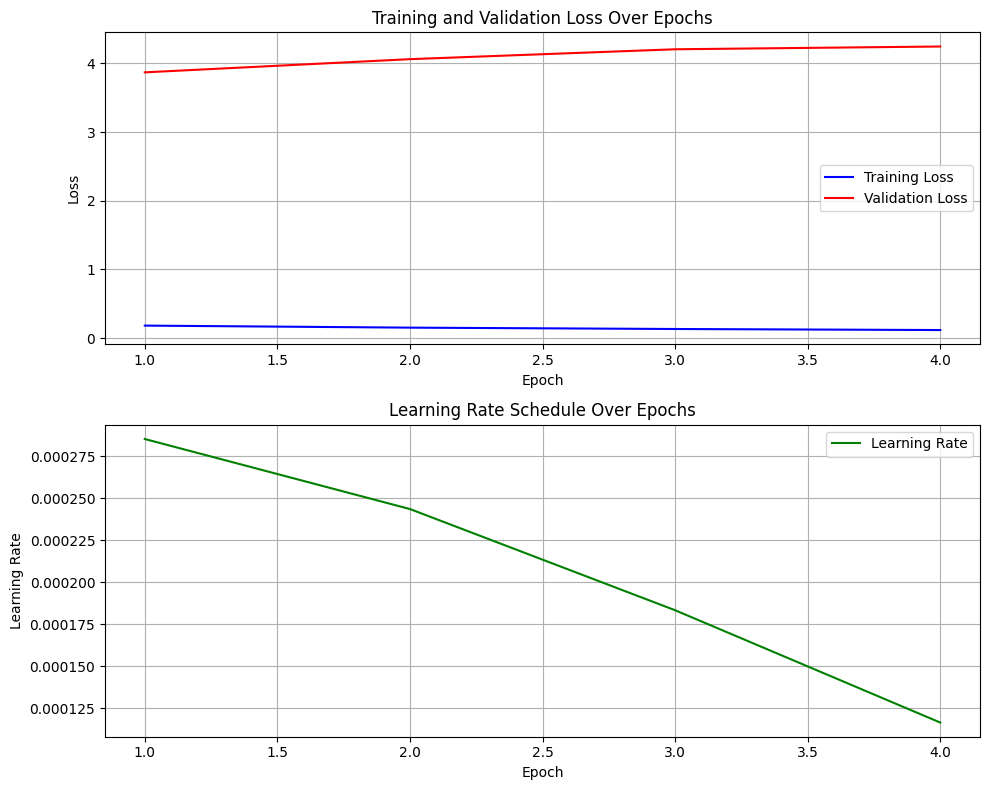

In [61]:
# Plot the training metrics
print("\nPlotting training metrics...")
plot_training_metrics(train_losses, val_losses, lrs)

In [68]:
ls -lh ./models/char_gpt_model.pth

-rw-r--r-- 1 root root 9.5M Feb 11 06:21 ./models/char_gpt_model.pth


## Earlier Version Training Logic


In [72]:
import torch

model_path = "models/char_gpt_model.pth"

# Load the state_dict
state_dict = torch.load(model_path, map_location='cpu')

print(f"Parameters in the saved model ({model_path}):")
for k, v in state_dict.items():
    print(f"Key: {k}, Shape: {v.shape}")

Parameters in the saved model (models/char_gpt_model.pth):
Key: _orig_mod.tok_emb.weight, Shape: torch.Size([67, 258])
Key: _orig_mod.pos_emb.weight, Shape: torch.Size([256, 258])
Key: _orig_mod.blocks.0.ln_1.weight, Shape: torch.Size([258])
Key: _orig_mod.blocks.0.ln_1.bias, Shape: torch.Size([258])
Key: _orig_mod.blocks.0.attn.c_attn.weight, Shape: torch.Size([774, 258])
Key: _orig_mod.blocks.0.attn.c_proj.weight, Shape: torch.Size([258, 258])
Key: _orig_mod.blocks.0.ln_2.weight, Shape: torch.Size([258])
Key: _orig_mod.blocks.0.ln_2.bias, Shape: torch.Size([258])
Key: _orig_mod.blocks.0.mlp.c_fc.weight, Shape: torch.Size([1032, 258])
Key: _orig_mod.blocks.0.mlp.c_proj.weight, Shape: torch.Size([258, 1032])
Key: _orig_mod.blocks.1.ln_1.weight, Shape: torch.Size([258])
Key: _orig_mod.blocks.1.ln_1.bias, Shape: torch.Size([258])
Key: _orig_mod.blocks.1.attn.c_attn.weight, Shape: torch.Size([774, 258])
Key: _orig_mod.blocks.1.attn.c_proj.weight, Shape: torch.Size([258, 258])
Key: _orig_m

In [12]:
def main():
    # Configuration
    config = CharGPTConfig()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load and prepare data
    try:
        with open('/content/shakespeare.txt', 'r', encoding='utf-8') as f:
            text = f.read()
    except FileNotFoundError:
        print("Shakespeare file not found. Creating sample data...")
        text = "Hello world! " * 1000  # Sample data for testing

    # Use more data for better training
    text = text[:100000]  # Increased from 20000

    # Create vocabulary
    chars = sorted(list(set(text)))
    vocab_size = len(chars)
    config.vocab_size = vocab_size

    print(f"Vocabulary size: {vocab_size}")
    print(f"Dataset size: {len(text)} characters")

    # Create mappings
    char_to_id = {ch: idx for idx, ch in enumerate(chars)}
    id_to_char = {idx: ch for ch, idx in char_to_id.items()}

    encoder = lambda s: [char_to_id[c] for c in s]
    decoder = lambda l: ''.join([id_to_char[i] for i in l])

    # Encode data
    data = torch.tensor(encoder(text), dtype=torch.long)

    # Create data loaders
    train_loader, val_loader = create_data_loaders(data, config)

    # Initialize model
    model = CharGPT(config).to(device)

    # Compile model for faster execution (PyTorch 2.0+)
    if config.compile_model and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)
            print("Model compiled successfully!")
        except Exception as e:
            print(f"Model compilation failed: {e}")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        betas=(0.9, 0.95)
    )

    scheduler = CosineAnnealingLR(optimizer, T_max=config.num_epochs)

    # Mixed precision training (updated API)
    if config.use_mixed_precision and torch.cuda.is_available():
        try:
            # Use new API if available (PyTorch 2.1+)
            scaler = torch.amp.GradScaler('cuda')
        except:
            # Fallback to old API
            scaler = torch.cuda.amp.GradScaler()
    else:
        scaler = None

    # Training loop
    print("Starting training...")
    for epoch in range(config.num_epochs):
        model.train()
        epoch_loss = 0
        num_batches = 0

        for batch_idx, (xb, yb) in enumerate(train_loader):
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if config.use_mixed_precision and scaler is not None:
                try:
                    # Use new API if available
                    with torch.amp.autocast('cuda'):
                        logits, loss = model(xb, yb)
                except:
                    # Fallback to old API
                    with torch.cuda.amp.autocast():
                        logits, loss = model(xb, yb)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                logits, loss = model(xb, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            # Print progress every 200 batches (less frequent)
            if batch_idx % 200 == 0:
                print(f"Epoch {epoch+1}/{config.num_epochs}, Batch {batch_idx}, Loss: {loss.item():.4f}")

        scheduler.step()

        # Validation
        val_loss = estimate_loss(model, val_loader, device)
        avg_train_loss = epoch_loss / num_batches

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f}, Val Loss {val_loss:.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

        # Generate sample text (less frequent)
        if epoch % 3 == 0 or epoch == config.num_epochs - 1:  # Every 3 epochs + final
            model.eval()
            context = torch.tensor([[char_to_id[list(char_to_id.keys())[0]]]], dtype=torch.long, device=device)
            generated = model.generate(context, max_new_tokens=100, temperature=0.8)
            print(f"Sample: {decoder(generated[0].tolist())[:200]}...")  # Truncate long samples
            print("-" * 50)

    print("Training completed!")

    # Save the trained model
    print("\nSaving model...")
    torch.save(model.state_dict(), 'models/char_gpt_trained.pth')

    # Final generation
    model.eval()
    context = torch.tensor([[char_to_id['T']]], dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=200, temperature=0.8)
    print("\nFinal generated text:")
    print(decoder(generated[0].tolist()))

    print("Done!")
